# Fonte de dados

**Pedido de Citação:**

Este conjunto de dados (dataset) está disponível publicamente para pesquisa. Os detalhes estão descritos em [Moro et al., 2014]. 
Por favor, inclua esta citação se você planeja usar esta base de dados:

> [Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, In press, http://dx.doi.org/10.1016/j.dss.2014.03.001

Disponível em: 
[pdf] http://dx.doi.org/10.1016/j.dss.2014.03.001
[bib] http://www3.dsi.uminho.pt/pcortez/bib/2014-dss.txt

---

**1. Título:** Bank Marketing (Marketing Bancário com contexto social/econômico)

**2. Fontes:**

*   **Criado por:** Sérgio Moro (ISCTE-IUL), Paulo Cortez (Univ. Minho) e Paulo Rita (ISCTE-IUL) @ 2014

**3. Uso Anterior:**

O conjunto de dados completo (`bank-additional-full.csv`) foi descrito e analisado em:

> S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems (2014), doi:10.1016/j.dss.2014.03.001.

**4. Informações Relevantes:**

Este conjunto de dados é baseado no dataset "Bank Marketing" da UCI (por favor, verifique a descrição em: http://archive.ics.uci.edu/ml/datasets/Bank+Marketing).
Os dados são enriquecidos pela adição de cinco novas características/atributos sociais e econômicos (indicadores nacionais de um país com ~10M de habitantes), publicados pelo Banco de Portugal e disponíveis publicamente em: https://www.bportugal.pt/estatisticasweb.

Este conjunto de dados é quase idêntico ao usado em [Moro et al., 2014] (ele não inclui todos os atributos devido a questões de privacidade).
Usando o pacote `rminer` e a ferramenta R (http://cran.r-project.org/web/packages/rminer/), descobrimos que a adição dos cinco novos atributos sociais e econômicos (disponibilizados aqui) levou a uma melhoria substancial na previsão de sucesso, mesmo quando a duração da chamada não é incluída. 
*Nota: o arquivo pode ser lido no R usando:* `d=read.table("bank-additional-full.csv",header=TRUE,sep=";")`

O arquivo zip inclui dois datasets:

1. `bank-additional-full.csv` com todos os exemplos, ordenados por data (de maio de 2008 a novembro de 2010).
2. `bank-additional.csv` com 10% dos exemplos (4.119), selecionados aleatoriamente do `bank-additional-full.csv`.

O dataset menor é fornecido para testar algoritmos de machine learning mais exigentes computacionalmente (ex., SVM).

O objetivo da classificação binária é prever se o cliente irá assinar/subscrever um depósito a prazo no banco (variável `y`).

**5. Número de Instâncias:** 41.188 para `bank-additional-full.csv`

**6. Número de Atributos:** 20 + atributo de saída.

**7. Informações dos Atributos:**

Para mais informações, leia [Moro et al., 2014].

**Variáveis de entrada (Input):**

*# dados do cliente bancário:*

1. `age`: idade (numérico)
2. `job`: tipo de emprego (categórico: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")
3. `marital`: estado civil (categórico: "divorced","married","single","unknown"; *nota: "divorced" significa divorciado ou viúvo*)
4. `education`: nível de escolaridade (categórico: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
5. `default`: tem crédito em inadimplência? (categórico: "no","yes","unknown")
6. `housing`: tem empréstimo imobiliário/habitação? (categórico: "no","yes","unknown")
7. `loan`: tem empréstimo pessoal? (categórico: "no","yes","unknown")

*# relacionado ao último contato da campanha atual:*

8. `contact`: tipo de comunicação do contato (categórico: "cellular","telephone")
9. `month`: mês do último contato no ano (categórico: "jan", "feb", "mar", ..., "nov", "dec")
10. `day_of_week`: dia da semana do último contato (categórico: "mon","tue","wed","thu","fri")

11. `duration`: duração do último contato, em segundos (numérico). *Nota importante: este atributo afeta fortemente o alvo de saída (ex., se duration=0 então y="no"). No entanto, a duração não é conhecida antes de uma chamada ser realizada. Além disso, após o término da chamada, o `y` é obviamente conhecido. Portanto, esta entrada deve ser incluída apenas para fins de benchmark (comparação) e deve ser descartada se a intenção for ter um modelo preditivo realista.*

*# outros atributos:*

12. `campaign`: número de contatos realizados durante esta campanha e para este cliente (numérico, inclui o último contato)
13. `pdays`: número de dias que se passaram desde que o cliente foi contatado pela última vez em uma campanha anterior (999 significa que o cliente não foi contatado anteriormente)
14. `previous`: número de contatos realizados antes desta campanha e para este cliente (numérico)
15. `poutcome`: resultado da campanha de marketing anterior (categórico: "failure","nonexistent","success")

*# atributos de contexto social e econômico:*

16. `emp.var.rate`: taxa de variação de emprego - indicador trimestral (numérico)
17. `cons.price.idx`: índice de preços ao consumidor - indicador mensal (numérico)
18. `cons.conf.idx`: índice de confiança do consumidor - indicador mensal (numérico)
19. `euribor3m`: taxa euribor a 3 meses - indicador diário (numérico)
20. `nr.employed`: número de empregados - indicador trimestral (numérico)

**Variável de saída (alvo desejado / target):**

21. `y`: o cliente assinou um depósito a prazo? (binário: "yes","no")

**8. Valores Ausentes nos Atributos (Missing Values):** 

Existem vários valores ausentes em alguns atributos categóricos, todos codificados com o rótulo "unknown" (desconhecido). Esses valores ausentes podem ser tratados como um possível rótulo de classe ou utilizando técnicas de exclusão (deletion) ou imputação.

# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
import mlflow
import joblib
import warnings

warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("bank_marketing_contextual_episolon_greedy")

2026/09/14 23:11:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/14 23:11:34 INFO mlflow.store.db.utils: Updating database tables
2026/09/14 23:11:35 INFO mlflow.tracking.fluent: Experiment with name 'bank_marketing_contextual_episolon_greedy' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/platero/postech-ml-engineering-fase-5-datathon/notebooks/mlruns/1', creation_time=1789438295695, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789438295695, lifecycle_stage='active', name='bank_marketing_contextual_episolon_greedy', tags={}, trace_location=None, workspace='default'>

### Preparação dos Dados

**Referência da Base:** Bank Marketing Dataset (Moro et al., 2014) hospedado no Kaggle.
* **Prevenção de Vazamento (Data Leakage):** Seguindo as restrições da regra de negócio, a coluna `duration` (duração da chamada) foi **descartada**, pois só é conhecida após o fim do contato, viciando o modelo preditivo.
* **Embaralhamento (Shuffle):** A base original é ordenada cronologicamente. Fizemos o *shuffle* dos dados para simular a chegada aleatória de clientes no mundo real, permitindo que o algoritmo online aprenda sem viés sazonal inicial.

In [2]:
df_war = pd.read_csv('data/bank-additional-full.csv', sep=';')

df = df_war.sample(frac=1, random_state=42).reset_index(drop=True)

#criando a variável alvo (y_true) como 0 ou 1
y_true = np.where(df['y'] == 'yes', 1, 0)

#separando as features (removendo o target 'y' e 'duration' para evitar data leakage)
X_raw = df.drop(columns=['y', 'duration'])

#identificando colunas numéricas e categóricas
numeric_features = X_raw.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_raw.select_dtypes(include=['object', 'category']).columns

#criando o pipeline de transformação (preprocessor)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

#gerando o X_processed que estava faltando!
X_processed = preprocessor.fit_transform(X_raw)
print("Pré-processamento concluído!")

Pré-processamento concluído!


### Definindo ganho e custo

Toda vez que abordamos um cliente oferecendo um produto, temos três cenários possíveis:

* **Lucro da Conversão ($R_{sucesso}$):** `+2.0`. É o valor financeiro que ganhamos se o cliente aceitar a oferta.
* **Custo de Atrito ($C_{custo}$):** `-0.5`. Se o cliente recusar, nós perdemos dinheiro (custo da ligação, tempo do operador e o desgaste do cliente com a marca).
* **Inação:** `0.0`. Se decidirmos não ofertar nada, não ganhamos nem perdemos.

---

### O Baseline

O Baseline representa como a empresa opera hoje: usando regras fixas baseadas em "achismos" ou cortes simples de dados.

* **A Estratégia:** O código faz uma oferta massiva para todo cliente que **não** possui financiamento habitacional (`housing == 'no'`).

* **O Problema:** Essa regra é cega. Ela não calcula o risco. Ao ofertar para todo mundo desse grupo, o sistema vai inevitavelmente tomar vários "nãos", acumulando o custo de atrito ($-0.5$) repetidas vezes, o que pode destruir a margem de lucro da campanha.

---

### Contextual Bandit Adaptativo

O algoritmo não segue uma regra fixa; ele age de forma adaptativa calculando o risco matemático de cada cliente antes de tomar uma decisão.

#### O Aquecimento (*Warm-up*)

No código, usamos os primeiros `500` clientes para treinar nosso modelo classificador (`SGDClassifier`). Assim, quando o Bandit começar a tomar decisões sozinho, ele já terá uma noção básica de probabilidade e não fará escolhas completamente aleatórias.

#### Exploração vs. Explotação (A Estratégia $\epsilon$-Greedy)

O algoritmo precisa testar explorar para descobrir nichos escondidos, mas também precisa focar no que historicamente dá retorno. Para tanto aplicamos o **Epsilon Decay**:

$$ \epsilon_t = \epsilon_{start} \times \left( 1 - \frac{t}{N} \right) $$

* **Exploração ($\epsilon$):** No início, em 15% das vezes, o modelo escolhe uma ação aleatória (ofertar ou não). Isso serve para ele aprender sobre clientes que normalmente ignoraria.
* **Explotação ($1 - \epsilon$):** Conforme o tempo avança e ele fica mais inteligente, a taxa de exploração cai linearmente em direção a zero. O algoritmo para de "chutar" e passa a usar apenas seu modelo preditivo para maximizar o lucro.

#### A Matemática da Decisão

Quando o modelo decide usar sua inteligência, ele não simplesmente oferta para quem tem "mais de 50% de chance". Ele aplica uma regra financeira para o valor esperado:

$$ EV = \Big[ P(Sucesso) \times 2.0 \Big] + \Big[ (1 - P(Sucesso)) \times (-0.5) \Big] $$

O modelo só faz a oferta se o retorno médio for positivo (if expected_value_offer > 0). Se igualarmos o EV a zero, descobrimos o ponto de equilíbrio:

$$ 2.5p - 0.5 = 0 \implies p = 0.20 $$

Ou seja, a inteligência do código descobriu sozinha que só vale a pena disparar a oferta se o cliente tiver mais de 20% de chance de aceitar. Abaixo disso, o risco de perder $0.5$ não compensa.

### O Aprendizado Contínuo (*Feedback Loop*)

No final do loop, temos o `model.partial_fit`. Isso é o *Online Machine Learning* em ação. 

Em vez de treinar o modelo de uma vez só com dados do passado, o algoritmo aprende instantaneamente após cada oferta. Ele ajusta seus "pesos" neurais naquela mesma fração de segundo e já vai mais inteligente para o próximo cliente.

In [3]:
def simulate_bandit_and_baseline(X, y_true, df_raw, epsilon_start=0.15, cost=-0.5, reward_success=2.0):
    n_samples = X.shape[0]
    
    #classificador online (sem pesos artificiais para manter a probabilidade calibrada real)
    model = SGDClassifier(loss='log_loss', learning_rate='invscaling', eta0=0.1, random_state=42)
    
    bandit_rewards = []
    baseline_rewards = []
    cumulative_bandit_reward = 0
    cumulative_baseline_reward = 0
    
    #warm-up (Deixa o modelo ver 500 clientes antes de começar a decidir sozinho)
    warmup = 500 
    model.partial_fit(X[:warmup], y_true[:warmup], classes=np.array([0, 1]))
    
    for t in range(warmup, n_samples):
        context = X[t].reshape(1, -1)
        actual_y = y_true[t]
        
        # ====================================================
        # BASELINE (Regra Fixa de Cross-Sell)
        # ====================================================
        baseline_action = 1 if df_raw.iloc[t]['housing'] == 'no' else 0
        r_base = reward_success if (baseline_action == 1 and actual_y == 1) else (cost if baseline_action == 1 else 0)
        cumulative_baseline_reward += r_base
        baseline_rewards.append(cumulative_baseline_reward)
        
        # ====================================================
        # ADAPTATIVO (Epsilon Decay)
        # ====================================================
        current_epsilon = epsilon_start * (1 - (t / n_samples)) 
        
        if np.random.rand() < current_epsilon:
            bandit_action = np.random.choice([0, 1]) #exploração
        else:
            prob_success = model.predict_proba(context)[0][1]
            expected_value_offer = (prob_success * reward_success) + ((1 - prob_success) * cost)
            bandit_action = 1 if expected_value_offer > 0 else 0 #explotação
            
        r_bandit = reward_success if (bandit_action == 1 and actual_y == 1) else (cost if bandit_action == 1 else 0)
        cumulative_bandit_reward += r_bandit
        bandit_rewards.append(cumulative_bandit_reward)
        
        #feedback Loop
        if bandit_action == 1:
            model.partial_fit(context, [actual_y])

    return model, bandit_rewards, baseline_rewards

### Rastreamento de Experimentos com MLflow

Garantindo as boas práticas de **Machine Learning Engineering**, vamos registrar os parâmetros, a estratégia de custos e empacotar os artefatos (Model e Preprocessor) para futuro deploy em Cloud (ex: Amazon SageMaker).

In [8]:
EPSILONS = [40, 30, 20, 10, 5]
COST_REAL = -0.5 
REWARD_REAL = 2.0 

for epsilon in EPSILONS:
    EPSILON_START = epsilon / 100

    with mlflow.start_run(run_name=f"bank_marketing_contextual_episolon_greedy_episolon_start_{EPSILON_START}"):
        
        mlflow.log_params({
            "epsilon_start": EPSILON_START,
            "epsilon_decay": True,
            "cost_of_failure": COST_REAL,
            "reward_of_success": REWARD_REAL,
            "algorithm": "Contextual Epsilon-Greedy (Calibrado)",
        })
        
        trained_bandit, rew_bandit, rew_baseline = simulate_bandit_and_baseline(
            X_processed, y_true, df, epsilon_start=EPSILON_START, cost=COST_REAL, reward_success=REWARD_REAL
        )
        
        mlflow.log_metrics({
            "Final_Bandit_Reward": rew_bandit[-1],
            "Final_Baseline_Reward": rew_baseline[-1],
        })
        
        mlflow.sklearn.log_model(trained_bandit, name="contextual_bandit_model")
        joblib.dump(preprocessor, "preprocessor.pkl")
        mlflow.log_artifact("preprocessor.pkl")

    print(f"Rastreamento concluído via MLflow!")

Rastreamento concluído via MLflow!
Rastreamento concluído via MLflow!
Rastreamento concluído via MLflow!
Rastreamento concluído via MLflow!
Rastreamento concluído via MLflow!


### Prova de Valor Financeiro
Abaixo, demonstramos visualmente o impacto de trocar a abordagem estática por uma plataforma de IA Adaptativa. O Gráfico evidencia o **rombo financeiro** causado pela regra massiva (Baseline) versus o **lucro maximizado** da abordagem contextual.

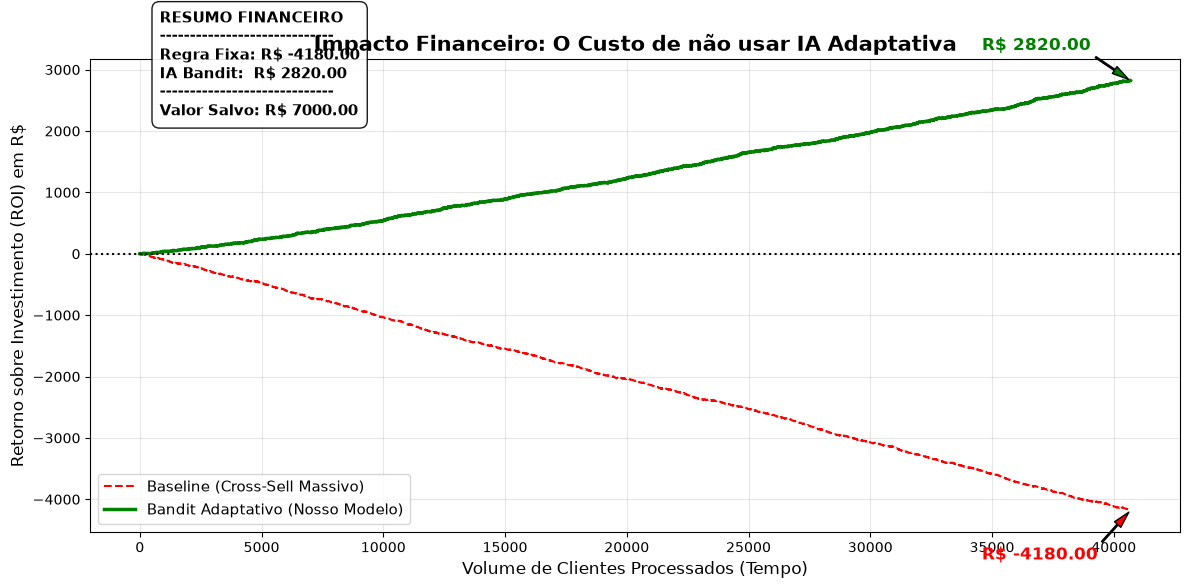

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(rew_baseline, label='Baseline (Cross-Sell Massivo)', color='red', linestyle='--')
plt.plot(rew_bandit, label='Bandit Adaptativo (Nosso Modelo)', color='green', linewidth=2.5)

plt.title('Impacto Financeiro: O Custo de não usar IA Adaptativa', fontsize=15, weight='bold')
plt.xlabel('Volume de Clientes Processados (Tempo)', fontsize=12)
plt.ylabel('Retorno sobre Investimento (ROI) em R$', fontsize=12)

#linha do zero
plt.axhline(0, color='black', linewidth=1.5, linestyle=':') 

final_base = rew_baseline[-1]
final_bandit = rew_bandit[-1]
ganho_real = final_bandit - final_base
total_clientes = len(rew_baseline)

#setas de anotação
plt.annotate(f'R$ {final_base:.2f}', xy=(total_clientes, final_base), xytext=(total_clientes * 0.85, final_base - 800),
             color='red', fontsize=12, weight='bold', arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6))
plt.annotate(f'R$ {final_bandit:.2f}', xy=(total_clientes, final_bandit), xytext=(total_clientes * 0.85, final_bandit + 500),
             color='green', fontsize=12, weight='bold', arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6))

#caixa de resumo executivo
resumo_texto = (f"RESUMO FINANCEIRO\n-----------------------------\n"
                f"Regra Fixa: R$ {final_base:.2f}\nIA Bandit:  R$ {final_bandit:.2f}\n"
                f"-----------------------------\nValor Salvo: R$ {ganho_real:.2f}")
plt.text(total_clientes * 0.02, max(rew_bandit) * 0.8, resumo_texto, fontsize=11, weight='bold', color='black',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Serviço e Casos de Teste (Golden Set) - Etapas 4 e 5
Para validar a assertividade na ponta do canal digital (ex: App do Banco), isolamos perfis variados. 
Nesta simulação de API, o modelo analisa as features, projeta o Valor Esperado (Lucro vs Risco) e decide de forma transparente se deve ou não emitir o push de oferta para o cliente.

In [6]:
#construção do Golden Set representativo
try:
    c1 = df[(df['job'] == 'retired') & (df['age'] >= 60)].iloc[[0]] 
    c2 = df[(df['job'] == 'student')].iloc[[0]]                     
    c3 = df[(df['job'] == 'blue-collar') & (df['default'] != 'no')].iloc[[0]] 
    c4 = df[(df['job'] == 'entrepreneur')].iloc[[0]]                
    c5 = df[(df['poutcome'] == 'success')].iloc[[0]]                
    golden_set_features = pd.concat([c1, c2, c3, c4, c5]).drop(columns=['y', 'duration'], errors='ignore')
except IndexError:
    golden_set_features = df.head(5).drop(columns=['y', 'duration'], errors='ignore')

#mock de API (interface de serviço)
def recommend_offer_final(client_data_df, model, preprocessor, cost, reward):
    X_client = preprocessor.transform(client_data_df)
    prob_success = model.predict_proba(X_client)[0][1]
    
    #decisão matemática (O coração financeiro do modelo)
    expected_value = (prob_success * reward) + ((1 - prob_success) * cost)
    decision = "FAZER OFERTA ✅" if expected_value > 0 else "NÃO OFERTAR ❌ (Risco de Prejuízo)"
    
    return decision, prob_success, expected_value

#execução das recomendações
print("=======================================================")
print("  RECOMENDAÇÕES DA PLATAFORMA ADAPTATIVA (INFERÊNCIA)  ")
print("=======================================================\n")

nomes_perfis = ["Idoso Aposentado", "Jovem Estudante", "Operário (Risco de Crédito)", "Empreendedor", "Cliente Fiel (Aceitou Anterior)"]

for i in range(len(golden_set_features)):
    client = golden_set_features.iloc[[i]]
    decision, prob, ev = recommend_offer_final(client, trained_bandit, preprocessor, COST_REAL, REWARD_REAL)
    
    print(f"👤 PERFIL {i+1}: {nomes_perfis[i]}")
    print(f"   - Características: Idade={client['age'].values[0]}, Profissão={client['job'].values[0]}, Campanha Ant.={client['poutcome'].values[0]}")
    print(f"   - Prob. de Conversão Prevista: {prob*100:.2f}%")
    print(f"   - Retorno Financeiro Esperado (EV): R$ {ev:.2f}")
    print(f"   - DECISÃO DA IA: {decision}")
    print("-" * 55)

  RECOMENDAÇÕES DA PLATAFORMA ADAPTATIVA (INFERÊNCIA)  

👤 PERFIL 1: Idoso Aposentado
   - Características: Idade=63, Profissão=retired, Campanha Ant.=nonexistent
   - Prob. de Conversão Prevista: 41.59%
   - Retorno Financeiro Esperado (EV): R$ 0.54
   - DECISÃO DA IA: FAZER OFERTA ✅
-------------------------------------------------------
👤 PERFIL 2: Jovem Estudante
   - Características: Idade=25, Profissão=student, Campanha Ant.=success
   - Prob. de Conversão Prevista: 76.60%
   - Retorno Financeiro Esperado (EV): R$ 1.41
   - DECISÃO DA IA: FAZER OFERTA ✅
-------------------------------------------------------
👤 PERFIL 3: Operário (Risco de Crédito)
   - Características: Idade=26, Profissão=blue-collar, Campanha Ant.=nonexistent
   - Prob. de Conversão Prevista: 7.99%
   - Retorno Financeiro Esperado (EV): R$ -0.30
   - DECISÃO DA IA: NÃO OFERTAR ❌ (Risco de Prejuízo)
-------------------------------------------------------
👤 PERFIL 4: Empreendedor
   - Características: Idade=24, Pr